<a href="https://colab.research.google.com/github/cafrancog/Analitica_De_Negocios/blob/main/Reto_6_Carlos_Franco.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* Reto 6
* Analítica de negocios
* Carlos Andrés Franco
* 3 de mayo de 2025

1. **Obtener paquetes y librerías**

In [1]:
# Modelo neuronal
!pip install tensorflow

import tensorflow as tf


# Manipulación de datos
import numpy as np
import pandas as pd

#Gráficas
import seaborn as sns
import matplotlib.pyplot as plt

# Base de datos
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


2. **Obtener los datos**

In [14]:
base_de_datos = pd.read_excel("/content/drive/MyDrive/Drive documents/Eafit/Septimo semestre/ANEG/S14/Reto 6/6. SolicitantesCrédito(USD).xlsx", sheet_name = 1)

datos = base_de_datos[["Edad", "Hijos", "Perscargo",
                       "Estrato", "Ingresos", "Egresos",
                       "Monto (EAD)", "Plazo", "Cuota (COP)", "Score"]]

datos.head()

#Buscar NaN

print(datos.isnull().sum())

#No hay NaN, se prosigue sin más acciones.






Edad           0
Hijos          0
Perscargo      0
Estrato        0
Ingresos       0
Egresos        0
Monto (EAD)    0
Plazo          0
Cuota (COP)    0
Score          0
dtype: int64


In [23]:
#Entrada

entrada = np.array(datos[["Edad", "Hijos", "Perscargo",
                       "Estrato", "Ingresos", "Egresos",
                       "Monto (EAD)", "Plazo", "Cuota (COP)"]])

#Salida

salida = np.array(datos[["Score"]])

# Pronosticar
pronosticar = [[45, 1, 0, 4, 2000, 1000, 1200, 24, 60]]

print("entrada", entrada)
print("salida", salida)

entrada [[3.80000000e+01 1.00000000e+00 0.00000000e+00 ... 6.25562230e+02
  4.80000000e+01 1.83758903e+01]
 [5.10000000e+01 6.00000000e+00 1.00000000e+00 ... 1.40031984e+02
  3.60000000e+01 5.06249169e+00]
 [3.70000000e+01 2.00000000e+00 0.00000000e+00 ... 2.84564492e+02
  3.60000000e+01 1.02876881e+01]
 ...
 [3.80000000e+01 0.00000000e+00 0.00000000e+00 ... 5.94947894e+02
  3.60000000e+01 2.15087916e+01]
 [4.30000000e+01 1.00000000e+00 2.00000000e+00 ... 3.05580539e+02
  3.60000000e+01 1.10474685e+01]
 [3.70000000e+01 1.00000000e+00 2.00000000e+00 ... 1.00563687e+03
  3.60000000e+01 3.63561819e+01]]
salida [[582.47894287]
 [479.83996582]
 [417.65310669]
 ...
 [465.01153564]
 [423.23730469]
 [592.6708374 ]]


3. **Normalizar los datos**

In [24]:
n_entrada = entrada/np.max(entrada, axis=0)
n_salida = salida/np.max(salida, axis=0)
n_pronosticar = pronosticar/np.max(entrada, axis=0)

print("entrada n", n_entrada.min(), n_entrada.max())
print("salida n", n_salida.min(), n_salida.max())
print("pronosticar n", n_pronosticar.min(), n_pronosticar.max())

entrada n 0.0 1.0
salida n 0.13746262309597096 1.0
pronosticar n 0.0 0.6678053304054521


4. **Red neuronal tipo ADALINE**

In [5]:
adaline = tf.keras.models.Sequential()
adaline.add(tf.keras.layers.Dense(units=1,
                              activation = "relu",
                              input_shape =(9,),
                              use_bias = False))

adaline.load_weights("/content/pesos_adaline_L.weights.h5")

adaline.compile(optimizer = "sgd", loss = "mse")

history = adaline.fit(n_entrada,
                  n_salida,
                  epochs = 100)

predicción_adaline = adaline.predict(n_entrada)


Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0128
Epoch 2/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0109
Epoch 3/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0089
Epoch 4/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0074
Epoch 5/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0061
Epoch 6/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0052
Epoch 7/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0045
Epoch 8/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0038
Epoch 9/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0035
Epoch 10/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.0029
Epoch 11/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0027
Epoch 12/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0024
Epoch 13/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.0021
Epoch 14/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.0019
Epoch 15/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step -

**Evaluar Resultados**

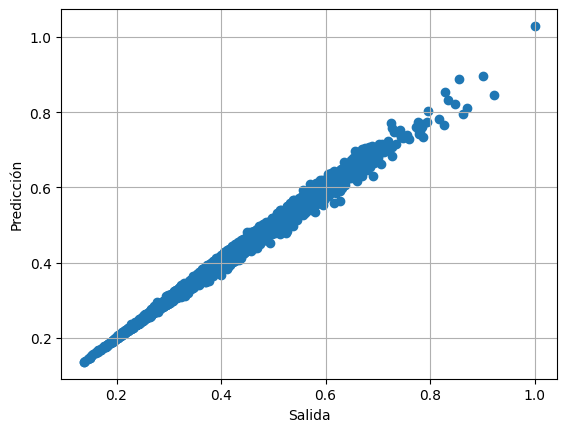

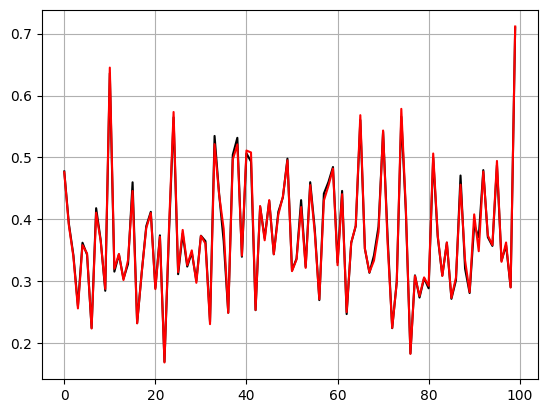

La correlación de los datos es:
           0         1
0  1.000000  0.996786
1  0.996786  1.000000
Las conexiones son:
 [array([[ 0.1643582 ],
       [ 0.03414849],
       [ 0.02631691],
       [ 0.16393657],
       [ 0.45933294],
       [-0.09109444],
       [ 0.08101737],
       [ 0.1569298 ],
       [ 0.31828517]], dtype=float32)]


In [11]:
plt.figure()
plt.scatter(n_salida, predicción_adaline)
plt.xlabel("Salida")
plt.ylabel("Predicción")
plt.grid()
plt.show()


plt.figure()
plt.plot(n_salida[0:100], color = "black")
plt.plot(predicción_adaline[0:100], color = "red")
plt.grid()
plt.show()





In [18]:
corr_adaline = pd.DataFrame(np.column_stack((n_salida,
                                             predicción_adaline)))
print("La correlación de los datos es:\n", corr_adaline.corr())


print("el coeficiente de correlación es de",
      np.corrcoef(n_salida.flatten(),predicción_adaline.flatten()))

La correlación de los datos es:
           0         1
0  1.000000  0.996786
1  0.996786  1.000000
el coeficiente de correlación es de [[1.         0.99678645]
 [0.99678645 1.        ]]


In [13]:

#Las conexiones nerviosas son
pesos_adaline = adaline.get_weights()
print("Las conexiones son:\n", pesos_adaline)

# contando desde 1, el objeto con mas peso es el 5 "Ingresos" con 0.4593
# seguido por la variable 9 "Cuota (COP)" con 0.3182

Las conexiones son:
 [array([[ 0.1643582 ],
       [ 0.03414849],
       [ 0.02631691],
       [ 0.16393657],
       [ 0.45933294],
       [-0.09109444],
       [ 0.08101737],
       [ 0.1569298 ],
       [ 0.31828517]], dtype=float32)]


5. **Pronostico de un nuevo crédito con ADALINE**

In [26]:
pronostico_adaline = adaline.predict(n_pronosticar)
print("El pronóstico de ADALINE es:", pronostico_adaline*np.max(salida, axis=0))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 95ms/step
El pronóstico de ADALINE es: [[733.60712664]]


6. **Modelo MADALINE**

In [32]:
madaline = tf.keras.models.Sequential([
    tf.keras.layers.Dense(10, input_shape=(9,),
                          activation = "relu",
                          use_bias = False),
    tf.keras.layers.Dense(1, activation = "relu",
                          use_bias = False)])

madaline.load_weights("/content/pesos_madaline_L.weights.h5")

madaline.compile(optimizer = "sgd", loss = "mse")

history2 = madaline.fit(n_entrada,
                  n_salida,
                  epochs = 100)

predicción_madaline = madaline.predict(n_entrada)

Epoch 1/100


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0025
Epoch 2/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0023
Epoch 3/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0022
Epoch 4/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0021
Epoch 5/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0019
Epoch 6/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0017
Epoch 7/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0016
Epoch 8/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0017
Epoch 9/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0015
Epoch 10/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0015
Epoch 11/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0014
Epoch 12/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0013
Epoch 13/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0014
Epoch 14/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 0.0013
Epoch 15/100
183/183 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step -

**Evaluar resultados MADALINE**

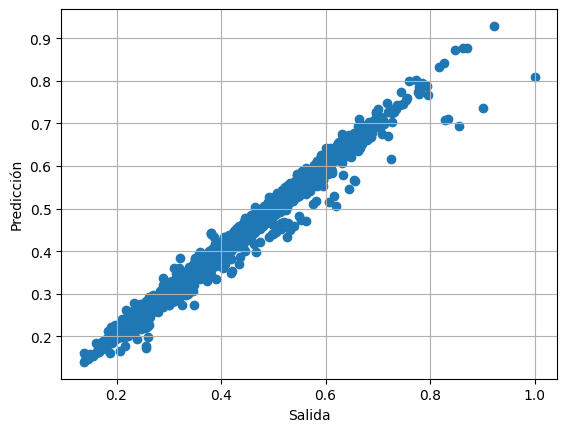

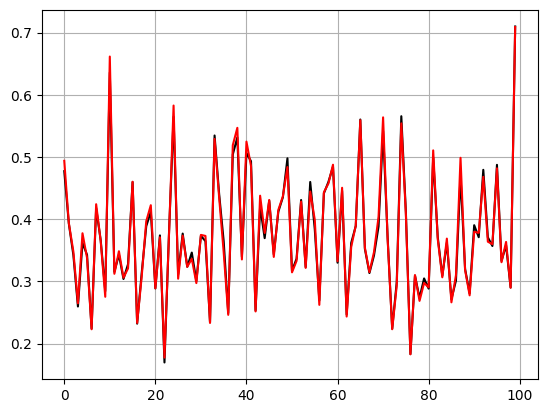

In [33]:
plt.figure()
plt.scatter(n_salida, predicción_madaline)
plt.xlabel("Salida")
plt.ylabel("Predicción")
plt.grid()
plt.show()


plt.figure()
plt.plot(n_salida[0:100], color = "black")
plt.plot(predicción_madaline[0:100], color = "red")
plt.grid()
plt.show()




In [34]:
corr_madaline = pd.DataFrame(np.column_stack((n_salida,
                                             predicción_madaline)))
print("La correlación de los datos es:\n", corr_madaline.corr())


print("el coeficiente de correlación es de",
      np.corrcoef(n_salida.flatten(),predicción_madaline.flatten()))

La correlación de los datos es:
           0         1
0  1.000000  0.993166
1  0.993166  1.000000
el coeficiente de correlación es de [[1.        0.9931658]
 [0.9931658 1.       ]]


In [36]:

#Las conexiones nerviosas son
wc = madaline.get_weights()

w = wc[0]

c = wc[1]

a = w@c

pesos_madaline = pd.DataFrame(a.T)
pesos_madaline.columns =["Edad", "Hijos", "Perscargo",
                       "Estrato", "Ingresos", "Egresos",
                       "Monto (EAD)", "Plazo", "Cuota (COP)"]
display(pesos_madaline)

,Edad,Hijos,Perscargo,Estrato,Ingresos,Egresos,Monto (EAD),Plazo,Cuota (COP)
0,0.201826,0.299269,-0.170805,0.297948,0.100575,0.300197,0.280574,0.291088,-0.202582


7. **Pronosticar un nuevo crédito con MADALINE**

In [37]:
pronostico_madaline = madaline.predict(n_pronosticar)
print("El pronóstico de MADALINE es:", pronostico_madaline*np.max(salida, axis=0))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
El pronóstico de MADALINE es: [[635.07907665]]


8. **Análisis**

Usando el modelo ADALINE según los parámetros solicitados, se encuentra que predice fielmente a la base de datos con la cual fué alimentado, las gráficas muestran una correlación estrecha entre los dos, y gran interpolación de lineas, y al calcular el coeficiente de correlación, se encuentra con una cifra de 0.9967, algo que demuestra la fiabilidad de este modelo.

La variable que mas incide en su proceso de decisión son los ingresos con un peso de 0.4593, y en segundo lugar se encuentra la cuota con un peso de 0.3182. Y la unica cuenta que se encontró con un peso negativo, son los egresos, pero con un peso mínimo comparado con los anteriores (-0.0910).

Al pronosticar un solicitante nuevo, el modelo lo califica con un Score de 733, lo que significaría que esta persona le sería aceptado su crédito sin necesidad de un codeudor (de acuerdo a lo expuesto en clase).


Por otro lado, el modelo MADALINE logra alcanzar resultados similares, sin embargo en la gráfica scatterplot surge un cambio de pendiente de algunos datos entre los valores x 0.4 y 1.0, lo que sugiere una menor fidelidad (al menos en los primeros 100 datos que fueron los graficados) frente a ADALINE. La gráfica de lineas muestra interpolación casi perfecta al igual que ADALINE, y su coeficiente de correlación es de 0.9931, el cual sigue siendo muy bueno, pero es 0.0030 menor a ADALINE, lo que demuestra en este caso que el primer modelo es mejor para esta situación.

Madaline utiliza como sus pesos mas significativos a hijos con 0.2993, seguido por estrato con 0.2979, y en este caso se encuentran dos pesos negativos, cuota siendo el mayor con -0.2025, y personas a cargo con -0.1708.

Al pronosticar el solicitante de crédito, MADALINE arroja resultados de 635, un Score casi 100 debajo de ADALINE, lo que es preocupante, dado a que la similaridad de la fidelidad de ambos modelos debería significar que los datos pronosticados no deberían tener mucha disparidad. Sin embargo, en este caso el solicitante tambien sería aprobado sin necesidad de co-deudor.

En conclusión, ambos modelos hacen un gran trabajo según las métricas de evaluación, pero la disparidad de resultados es preocupante dado la similaridad de su desempeño, lo cual convendría llevarse a un mayor análisis, como evaluar el desempeño con datos que no haya sido entrenado para descartar una posible memorización y no razonamiento, así como incluir otras métricas en caso de ser posible como la matríz de confusión. Mi recomendación es no ponerlos en uso real hasta asegurarse de que funcionen perfectamente.